# PCA Cluster-wise Intermolecular Interaction Analysis: Ligand-47

This notebook computes and visualizes **cluster-wise intermolecular interaction features for Ligand-47** using the PCA-derived cluster assignments generated in the main PCA workflow.

**Important dependency:** this notebook uses the discrete trajectory (`dtraj`) produced by the `PCA_both.ipynb` notebook. The `dtraj` assigns each simulation frame to a PCA cluster, allowing the trajectory to be split into cluster-specific frame groups for downstream interaction analysis.

## Workflow overview

1. Load the Ligand-47 trajectory, topology, and PCA cluster assignments.
2. Define ligand/protein atom groups and interaction-detection helper functions.
3. Split frames by PCA cluster using `dtraj`.
4. Calculate cluster-wise intermolecular interaction features, including contacts, charge interactions, hydrophobic contacts, aromatic interactions, and hydrogen bonds.
5. Visualize cluster-level interaction patterns.
6. Save `.npy` outputs that can be reloaded in `PCA_both.ipynb` for side-by-side comparison between Fasudil and Ligand-47.

The purpose of this notebook is to connect PCA-defined structural clusters with their underlying biochemical interaction fingerprints, so that each cluster can be interpreted as a distinct binding mode rather than only a mathematical grouping.


## Imports and molecular-geometry utilities

This cell imports the core scientific Python libraries and MDTraj tools used for trajectory loading, atom selections, geometric measurements, and interaction calculations.

In [1]:
from __future__ import print_function, division
import mdtraj as md
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from mdtraj.geometry import _geometry
import os
import sys
import numpy as np
import pandas
import scipy 
from scipy import optimize
from scipy.optimize import leastsq
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import math
import itertools    
from numpy import log2, zeros, mean, var, sum, loadtxt, arange, array, cumsum, dot, transpose, diagonal, floor
from numpy.linalg import inv, lstsq
import pyblock
from mdtraj.geometry import _geometry
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from scipy.stats import pearsonr
import pickle
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

## Imports for dimensionality reduction, MSM analysis, and plotting

This cell imports PyEMMA, Deeptime, plotting, and numerical-analysis libraries used by the broader PCA/MSM workflow and for visualizing cluster-level interaction patterns.

In [2]:
import pyemma.coordinates as coor
import pyemma.msm as msm
import pyemma.plots as mplt
import deeptime
from deeptime.decomposition import TICA
import pyemma
from deeptime.clustering import KMeans

## Check the current working directory

This cell prints the active directory so file paths can be verified before loading trajectories or saving outputs.

In [3]:
!pwd

/data/asn/tica/lig_47/combined


## Small dataframe test

This cell creates a simple example dataframe, likely used as a quick check that pandas is imported and working correctly.

In [4]:
d = {i:np.arange(10) for i in range(10)}
df = pandas.DataFrame(d)

## Load Ligand-47 simulation data and PCA cluster assignments

This cell defines file paths, loads the Ligand-47 topology and trajectory data, and loads the PCA-derived `dtraj` generated from the `PCA_both.ipynb` notebook. The `dtraj` is the key input that maps trajectory frames to PCA clusters.

In [4]:
traj_dir='/data/asn/tica/lig47/combined/'
pdb = '/data/asn/biorxiv2021-6626290-no-water-glue/lig47.pdb'
rep0 = '/data/asn/biorxiv2021-6626290-no-water-glue/ligand_47_1.xtc'
dtraj= np.load('/data/asn/tica/lig_47/combined/dtraj_pca_combined_feature_lig_47.npy')

traj = md.load(rep0, top=pdb)
#trj.center_coordinates()
#top = trj.topology

k = 4
frames_cl = [np.where(dtraj==i)[0] for i in range(k)]
    
xtc=[]
trj={}
top={}
for i in range(0,k):
    #xtc=traj_dir+"fusadil_cluster8_"+str(i)+'_d4.dcd'

    trj[i] = traj[frames_cl[i]]
    trj[i].center_coordinates()
    top[i] = trj[i].topology

    print(trj[i].n_frames)#,trj[1].unitcell_lengths[0][0])

#n_frames=trj.n_frames
box_len=trj[1].unitcell_lengths[0][0]
top=trj[1].topology
print(top)

216423
325699
355216
203551
<mdtraj.Topology with 1 chains, 22 residues, 338 atoms, 296 bonds>


## Inspect the shape of the discrete trajectory

This cell checks the dimensions of `dtraj` to confirm that the cluster-assignment array was loaded correctly.

In [8]:
dtraj.shape

(1100889,)

## Inspect the number of trajectory frames

This cell checks the total number of frames in the loaded trajectory so it can be compared against the length of the discrete trajectory.

In [9]:
traj.n_frames

1100889

## Define ligand interaction atom groups

This cell defines ligand atom indices used for aromatic ring detection, hydrogen-bond donor/acceptor definitions, and other interaction-specific calculations.

In [5]:
# Define Aromatic Rings
ligand_rings=[[307,308,309,311,313,314]]

# Definie Hydrogen Bond Donors
lig_hbond_donors=[[329,331],[329,330]]

#Select Ligand Charge Groups
#Ligand Charged atom is N-296
Ligand_Pos_Charges=[329]
Ligand_Neg_Charges=[]

residues = 21
residue_offset = 121
residue_number = range(0, residues)
residue_number_offset = range(residue_offset, residue_offset+residues)

## Define reusable interaction-analysis functions

This cell contains helper functions used throughout the notebook to calculate geometric properties, residue-level contacts, interaction frequencies, and statistical uncertainties. These functions form the main analysis toolkit for converting PCA clusters into interpretable interaction fingerprints.

In [6]:
# block function from pyblock package -  https://github.com/jsspencer/pyblock
# Estimates statistical inefficiency and uncertainty using block averaging.
def block(x):
    # preliminaries
    d = log2(len(x))
    if (d - floor(d) != 0):
        x = x[:2**int(floor(d))]
    d = int(floor(d))
    n = 2**d
    s, gamma = zeros(d), zeros(d)
    mu = mean(x)
    # estimate the auto-covariance and variances
    # for each blocking transformation
    for i in arange(0, d):
        n = len(x)
        # estimate autocovariance of x
        gamma[i] = (n)**(-1)*sum((x[0:(n-1)]-mu)*(x[1:n]-mu))
        # estimate variance of x
        s[i] = var(x)
        # perform blocking transformation
        x = 0.5*(x[0::2] + x[1::2])

    # generate the test observator M_k from the theorem
    M = (cumsum(((gamma/s)**2*2**arange(1, d+1)[::-1])[::-1]))[::-1]

    # we need a list of magic numbers
    q = array([6.634897,  9.210340,  11.344867, 13.276704, 15.086272,
              16.811894, 18.475307, 20.090235, 21.665994, 23.209251,
              24.724970, 26.216967, 27.688250, 29.141238, 30.577914,
              31.999927, 33.408664, 34.805306, 36.190869, 37.566235,
              38.932173, 40.289360, 41.638398, 42.979820, 44.314105,
              45.641683, 46.962942, 48.278236, 49.587884, 50.892181])

    # use magic to determine when we should have stopped blocking
    for k in arange(0, d):
        if(M[k] < q[k]):
            break
    if (k >= d-1):
        print("Warning: Use more data")

    return (s[k]/2**(d-k))


# Defines the `free_energy_1D_blockerror` helper used in the cluster interaction workflow.
def free_energy_1D_blockerror(a, T, x0, xmax, bins, blocks):
    histo, xedges = np.histogram(
        a, bins=bins, range=[x0, xmax], density=True, weights=None)
    max = np.max(histo)
    # free_energy=-(0.001987*T)*np.log(histo)
    free_energy = -(0.001987*T)*np.log(histo+.000001)
    free_energy = free_energy-np.min(free_energy)
    xcenters = xedges[:-1] + np.diff(xedges)/2
    Ind = chunkIt(len(a), blocks)
    block_size = (Ind[0][1]-Ind[0][0])
    hist_blocks = []
    for i in range(0, len(Ind)):
        block_data = a[Ind[i][0]:Ind[i][1]]
        hist, binedges = np.histogram(block_data, bins=bins, range=[
                                      x0, xmax], density=True, weights=None)
        hist_blocks.append(hist)
    hist_blocks = np.array(hist_blocks)
    average = np.average(hist_blocks, axis=0)
    variance = np.var(hist_blocks, axis=0)
    N = len(hist_blocks)
    error = np.sqrt(variance / N)
    ferr = -(0.001987*T)*(error / average)
    return free_energy, xcenters, ferr


# Defines the `chunkIt` helper used in the cluster interaction workflow.
def chunkIt(a, num):
    avg = a / float(num)
    out = []
    last = 0.0
    while last < a-1:
        out.append([int(last), int(last+avg)])
        last += avg
    return out


# Defines the `histo_blockerror` helper used in the cluster interaction workflow.
def histo_blockerror(a, x0, xmax, bins, blocks):
    histo, xedges = np.histogram(
        a, bins=bins, range=[x0, xmax], density=True, weights=None)
    xcenters = xedges[:-1] + np.diff(xedges)/2
    Ind = chunkIt(len(a), blocks)
    block_size = (Ind[0][1]-Ind[0][0])
    hist_blocks = []
    for i in range(0, len(Ind)):
        block_data = a[Ind[i][0]:Ind[i][1]]
        hist, binedges = np.histogram(block_data, bins=bins, range=[
                                      x0, xmax], density=True, weights=None)
        hist_blocks.append(hist)
    hist_blocks = np.array(hist_blocks)
    average = np.average(hist_blocks, axis=0)
    variance = np.var(hist_blocks, axis=0)
    N = len(hist_blocks)
    error = np.sqrt(variance / N)
    return average, xcenters, error


# Defines the `Kd_calc` helper used in the cluster interaction workflow.
def Kd_calc(bound, conc):
    return((1-bound)*conc/bound)


# Defines the `get_blockerrors` helper used in the cluster interaction workflow.
def get_blockerrors(Data, bound_frac):
    n_data = len(Data[0])
    block_errors = []
    ave = []
    for i in range(0, n_data):
        data = Data[:, i]
        average = np.average(data)
        be = block(data)**.5
        ave.append(np.average(data))
        block_errors.append(be)
    ave_bf = np.asarray(ave)/bound_frac
    be_bf = np.asarray(block_errors)/bound_frac

    return ave_bf, be_bf


# Defines the `get_blockerrors_pyblock` helper used in the cluster interaction workflow.
def get_blockerrors_pyblock(Data, bound_frac):
    n_data = len(Data[0])
    block_errors = []
    ave = []
    for i in range(0, n_data):
        data = Data[:, i]
        average = np.average(data)
        if (average != 0) and (average != 1):
            reblock_data = pyblock.blocking.reblock(data)
            opt = pyblock.blocking.find_optimal_block(
                len(data), reblock_data)[0]
            opt_block = reblock_data[opt]
            be = opt_block[4]
        else:
            be = 0
        ave.append(average)
        block_errors.append(be)

    ave_bf = np.asarray(ave)/bound_frac
    be_bf = np.asarray(block_errors)/bound_frac
    return ave_bf, be_bf


# Defines the `get_blockerror` helper used in the cluster interaction workflow.
def get_blockerror(Data):
    data = Data
    average = np.average(data)
    be = block(data)**.5
    return average, be


# Defines the `get_blockerror_pyblock` helper used in the cluster interaction workflow.
def get_blockerror_pyblock(Data):
    average = np.average(Data)
    if (average != 0) and (average != 1):
        reblock_data = pyblock.blocking.reblock(Data)
        opt = pyblock.blocking.find_optimal_block(len(Data), reblock_data)[0]
        be = reblock_data[opt][4]
    else:
        be = 0
    return average, float(be)


# Defines the `get_blockerror_pyblock_nanskip` helper used in the cluster interaction workflow.
def get_blockerror_pyblock_nanskip(Data):
    average = np.average(Data)
    if (average != 0) and (average != 1):
        reblock_data = pyblock.blocking.reblock(Data)
        opt = pyblock.blocking.find_optimal_block(len(Data), reblock_data)[0]
        if(math.isnan(opt)):
            be_max = 0
            for i in range(0, len(reblock_data)):
                be = reblock_data[i][4]
                if(be > be_max):
                    be_max = be
        else:
            be = reblock_data[opt][4]
    else:
        be = 0
    return average, float(be)

# Calculates mean values and block errors while skipping missing values.
def get_blockerrors_pyblock_nanskip(Data, bound_frac):
    n_data = len(Data[0])
    block_errors = []
    ave = []
    for i in range(0, n_data):
        data = Data[:, i]
        average = np.average(data)
        if (average != 0) and (average != 1):
            reblock_data = pyblock.blocking.reblock(data)
            opt = pyblock.blocking.find_optimal_block(len(data), reblock_data)[0]
 #           opt_block = reblock_data[opt]
 #           be = opt_block[4]
            if (math.isnan(opt)):
                be_max=0
                for i in range(0, len(reblock_data)):
                    be = reblock_data[i][4]
                    if (be > be_max) :
                        be_max=be
            else:
                be = reblock_data[opt][4]
            
        else:
            be = 0
        ave.append(average)
        block_errors.append(be)

    ave_bf = np.asarray(ave)/bound_frac
    be_bf = np.asarray(block_errors)/bound_frac
    return ave_bf, be_bf

# Defines the `get_blockerror_pyblock_max` helper used in the cluster interaction workflow.
def get_blockerror_pyblock_max(Data):
    average=np.average(Data)
    if (average!=0) and (average!=1):
        reblock_data = pyblock.blocking.reblock(Data)
        be_max=0
        for i in range(0,len(reblock_data)): 
            be=reblock_data[i][4]
            if(be > be_max):
                be_max=be
    else:
        be=0
    return average,float(be)

# Defines the `calc_SA` helper used in the cluster interaction workflow.
def calc_SA(trj, helix, start, stop):
    r0 = .10
    RMS_start = start
    RMS_stop = stop
    RMS = []
    for i in range(RMS_start, RMS_stop):
        sel = helix.topology.select("residue %s to %s and name CA" % (i, i+6))
        rmsd = md.rmsd(trj, helix, atom_indices=sel)
        RMS.append(rmsd)
    RMS = np.asarray(RMS)
    Sa_sum = np.zeros((trj.n_frames))
    Sa = (1.0-(RMS/0.10)**8)/(1-(RMS/0.10)**12)
    return Sa


# Defines the `calc_Rg` helper used in the cluster interaction workflow.
def calc_Rg(trj):
    mass = []
    for at in trj.topology.atoms:
        mass.append(at.element.mass)
    mass_CA = len(mass)*[0.0]
    for i in trj.topology.select("name CA"):
        mass_CA[i] = 1.0
    rg_CA = md.compute_rg(trj, masses=np.array(mass_CA))
    return rg_CA


# Defines the `free_energy` helper used in the cluster interaction workflow.
def free_energy(a, b, T, y0, ymax, x0, xmax):
    free_energy, xedges, yedges = np.histogram2d(
        a, b, 30, [[y0, ymax], [x0, xmax]], normed=True, weights=None)
    free_energy = np.log(np.flipud(free_energy)+.000001)
    free_energy = -(0.001987*T)*free_energy
    return free_energy, xedges, yedges


# Defines the `free_energy_reweight` helper used in the cluster interaction workflow.
def free_energy_reweight(a, b, T, y0, ymax, x0, xmax, weight):
    free_energy, xedges, yedges = np.histogram2d(
        a, b, 30, [[y0, ymax], [x0, xmax]], normed=True, weights=weight)
    free_energy = np.log(np.flipud(free_energy)+.000001)
    free_energy = -(0.001987*T)*free_energy
    return free_energy, xedges, yedges


# Defines the `free_energy_1D_noscale` helper used in the cluster interaction workflow.
def free_energy_1D_noscale(a, T, x0, xmax, bins):
    free_energy, xedges = np.histogram(
        a, bins=bins, range=[x0, xmax], density=True, weights=None)
    free_energy = np.log(free_energy+.000001)
    free_energy = -(0.001987*T)*free_energy
    xcenters = xedges[:-1] + np.diff(xedges)/2
    return free_energy, xcenters


# Defines the `free_energy_1D` helper used in the cluster interaction workflow.
def free_energy_1D(a, T, x0, xmax, bins):
    free_energy, xedges = np.histogram(
        a, bins=bins, range=[x0, xmax], density=True, weights=None)
    max = np.max(free_energy)
    free_energy = np.log(free_energy+.0000001)
    free_energy = -(0.001987*T)*(free_energy-np.log(max+.0000001))
    xcenters = xedges[:-1] + np.diff(xedges)/2
    return free_energy, xcenters


# Defines the `free_energy_1D_reweight` helper used in the cluster interaction workflow.
def free_energy_1D_reweight(a, T, x0, xmax, bins, weight):
    free_energy, xedges = np.histogram(
        a, bins=bins, range=[x0, xmax], density=True, weights=weight)
    max = np.max(free_energy)
    free_energy = np.log(free_energy+.0000001)
    free_energy = -(0.001987*T)*(free_energy-np.log(max+.0000001))
    xcenters = xedges[:-1] + np.diff(xedges)/2
    return free_energy, xcenters


# Defines the `alphabeta_rmsd` helper used in the cluster interaction workflow.
def alphabeta_rmsd(phi, psi, phi_ref, psi_ref):
    alphabetarmsd = np.sum(0.5*(1+np.cos(psi-psi_ref)),
                           axis=1)+np.sum(0.5*(1+np.cos(phi-phi_ref)), axis=1)
    return alphabetarmsd


# Defines the `dssp_convert` helper used in the cluster interaction workflow.
def dssp_convert(dssp):
    dsspH = np.copy(dssp)
    dsspE = np.copy(dssp)
    dsspH[dsspH == 'H'] = 1
    dsspH[dsspH == 'E'] = 0
    dsspH[dsspH == 'C'] = 0
    dsspH[dsspH == 'NA'] = 0
    dsspH = dsspH.astype(int)
    TotalH = np.sum(dsspH, axis=1)
    SE_H = np.zeros((len(dssp[0]), 2))

    for i in range(0, len(dssp[0])):
        data = dsspH[:, i].astype(float)
        if(np.mean(data) > 0):
            SE_H[i] = [np.mean(data), (block(data))**.5]

    dsspE[dsspE == 'H'] = 0
    dsspE[dsspE == 'E'] = 1
    dsspE[dsspE == 'C'] = 0
    dsspE[dsspE == 'NA'] = 0
    dsspE = dsspE.astype(int)
    TotalE = np.sum(dsspE, axis=1)
    Eprop = np.sum(dsspE, axis=0).astype(float)/len(dsspE)
    SE_E = np.zeros((len(dssp[0]), 2))

    for i in range(0, len(dssp[0])):
        data = dsspE[:, i].astype(float)
        if(np.mean(data) > 0):
            SE_E[i] = [np.mean(data), (block(data))**.5]
    return SE_H, SE_E


# Defines the `calc_phipsi` helper used in the cluster interaction workflow.
def calc_phipsi(trj):
    indices_phi, phis = md.compute_phi(trj)
    indices_psi, psis = md.compute_psi(trj)
    phi_label = []
    for i_phi in range(0, indices_phi.shape[0]):
        resindex = trj.topology.atom(indices_phi[i_phi][2]).residue.resSeq
        phi_label.append(resindex)
    phi_label = np.array(phi_label)
    psi_label = []
    for i_psi in range(0, indices_psi.shape[0]):
        resindex = trj.topology.atom(indices_psi[i_psi][2]).residue.resSeq
        psi_label.append(resindex)
    psi_label = np.array(psi_label)
    phipsi = []
    for i in range(0, len(phi_label)-1):
        current_phipsi = np.column_stack((phis[:, i+1], psis[:, i]))
        phipsi.append(current_phipsi)
    phipsi_array = np.array(phipsi)
    return(phipsi_array, psi_label, phi_label)

# Functions to Calculate Aromatic Stacking Interactions

# Defines the `find_plane_normal` helper used in the cluster interaction workflow.
def find_plane_normal(points):

    N = points.shape[0]
    A = np.concatenate((points[:, 0:2], np.ones((N, 1))), axis=1)
    B = points[:, 2]
    out = lstsq(A, B, rcond=-1)
    na_c, nb_c, d_c = out[0]
    if d_c != 0.0:
        cu = 1./d_c
        bu = -nb_c*cu
        au = -na_c*cu
    else:
        cu = 1.0
        bu = -nb_c
        au = -na_c
    normal = np.asarray([au, bu, cu])
    normal /= math.sqrt(dot(normal, normal))
    return normal


# Defines the `find_plane_normal2` helper used in the cluster interaction workflow.
def find_plane_normal2(positions):
    # Alternate approach used to check sign - could the sign check cause descrepency with desres?
    # Use Ligand IDs 312, 308 and 309 to check direction
    # [304 305 306 307 308 309 310 311 312 313]
    v1 = positions[0]-positions[1]
    v1 /= np.sqrt(np.sum(v1**2))
    v2 = positions[2]-positions[1]
    v2 /= np.sqrt(np.sum(v2**2))
    normal = np.cross(v1, v2)
    return normal


# Defines the `find_plane_normal2_assign_atomid` helper used in the cluster interaction workflow.
def find_plane_normal2_assign_atomid(positions, id1, id2, id3):
    # Alternate approach used to check sign - could the sign check cause descrepency with desres?
    v1 = positions[id1]-positions[id2]
    v1 /= np.sqrt(np.sum(v1**2))
    v2 = positions[id3]-positions[id1]
    v2 /= np.sqrt(np.sum(v2**2))
    normal = np.cross(v1, v2)
    return normal


# Computes aromatic interaction features from ligand and protein ring definitions.
def get_ring_center_normal_assign_atomid(positions, id1, id2, id3):
    center = np.mean(positions, axis=0)
    normal = find_plane_normal(positions)
    normal2 = find_plane_normal2_assign_atomid(positions, id1, id2, id3)
    # check direction of normal using dot product convention
    comp = np.dot(normal, normal2)
    if comp < 0:
        normal = -normal
    return center, normal


# Computes aromatic interaction features from ligand and protein ring definitions.
def get_ring_center_normal_(positions):
    center = np.mean(positions, axis=0)
    normal = find_plane_normal(positions)
    normal2 = find_plane_normal2(positions)
    # check direction of normal using dot product convention
    comp = np.dot(normal, normal2)
    if comp < 0:
        normal = -normal
    return center, normal


# Computes angle-based structural descriptors for selected atoms.
def angle(v1, v2):
    return np.arccos(np.dot(v1, v2)/(np.sqrt(np.dot(v1, v1))*np.sqrt(np.dot(v2, v2))))


# Computes aromatic interaction features from ligand and protein ring definitions.
def get_ring_center_normal_trj_assign_atomid(position_array, id1, id2, id3):
    length = len(position_array)
    centers = np.zeros((length, 3))
    normals = np.zeros((length, 3))
    centers_normals = np.zeros((length, 2, 3))
    print(np.shape(length), np.shape(centers), np.shape(normals))
    for i in range(0, len(position_array)):
        center, normal = get_ring_center_normal_assign_atomid(
            position_array[i], id1, id2, id3)
        centers_normals[i][0] = center
        centers_normals[i][1] = normal
    return centers_normals

# MDtraj Functions to Calculate Hydrogen Bonds with custom selections of donors and acceptors

# Defines the `_get_bond_triplets_print` helper used in the cluster interaction workflow.
def _get_bond_triplets_print(topology, lig_donors, exclude_water=True, sidechain_only=False):
    # Defines the `can_participate` helper used in the cluster interaction workflow.
    def can_participate(atom):
        # Filter waters
        if exclude_water and atom.residue.is_water:
            return False
        # Filter non-sidechain atoms
        if sidechain_only and not atom.is_sidechain:
            return False
        # Otherwise, accept it
        return True

    # Defines the `get_donors` helper used in the cluster interaction workflow.
    def get_donors(e0, e1):
        # Find all matching bonds
        # print("get_donors e0 e1:",e0,e1)
        elems = set((e0, e1))
        atoms = [(one, two) for one, two in topology.bonds
                 if set((one.element.symbol, two.element.symbol)) == elems]
        # Filter non-participating atoms
        atoms = [atom for atom in atoms
                 if can_participate(atom[0]) and can_participate(atom[1])]
        # Get indices for the remaining atoms
        indices = []
        for a0, a1 in atoms:
            pair = (a0.index, a1.index)
            # make sure to get the pair in the right order, so that the index
            # for e0 comes before e1
            if a0.element.symbol == e1:
                pair = pair[::-1]
            indices.append(pair)

        return indices

    # Check that there are bonds in topology
    nbonds = 0
    for _bond in topology.bonds:
        nbonds += 1
        break  # Only need to find one hit for this check (not robust)
    if nbonds == 0:
        raise ValueError('No bonds found in topology. Try using '
                         'traj._topology.create_standard_bonds() to create bonds '
                         'using our PDB standard bond definitions.')

    nh_donors = get_donors('N', 'H')
    print("nh_donors", nh_donors)
    for i in nh_donors:
        print(top.atom(i[0]), top.atom(i[1]))
    oh_donors = get_donors('O', 'H')
    print("oh_donors", oh_donors)
    for i in oh_donors:
        print(top.atom(i[0]), top.atom(i[1]))
    sh_donors = get_donors('S', 'H')
    print("sh_donors", sh_donors)
    for i in sh_donors:
        print(top.atom(i[0]), top.atom(i[1]))
    for i in lig_donors:
        print(top.atom(i[0]), top.atom(i[1]))
    # ADD IN ADDITIONAL SPECIFIED LIGAND DONORS
    xh_donors = np.array(nh_donors + oh_donors + sh_donors+lig_donors)

    if len(xh_donors) == 0:
        # if there are no hydrogens or protein in the trajectory, we get
        # no possible pairs and return nothing
        return np.zeros((0, 3), dtype=int)

    acceptor_elements = frozenset(('O', 'N', 'S'))
    acceptors = [a.index for a in topology.atoms
                 if a.element.symbol in acceptor_elements and can_participate(a)]
    print("acceptors")
    for i in acceptors:
        print(top.atom(i))
    # Make acceptors a 2-D numpy array
    acceptors = np.array(acceptors)[:, np.newaxis]

    # Generate the cartesian product of the donors and acceptors
    xh_donors_repeated = np.repeat(xh_donors, acceptors.shape[0], axis=0)
    acceptors_tiled = np.tile(acceptors, (xh_donors.shape[0], 1))
    bond_triplets = np.hstack((xh_donors_repeated, acceptors_tiled))

    # Filter out self-bonds
    self_bond_mask = (bond_triplets[:, 0] == bond_triplets[:, 2])
    return bond_triplets[np.logical_not(self_bond_mask), :]


# Defines the `_get_bond_triplets` helper used in the cluster interaction workflow.
def _get_bond_triplets(topology, lig_donors, exclude_water=True, sidechain_only=False):
    # Defines the `can_participate` helper used in the cluster interaction workflow.
    def can_participate(atom):
        # Filter waters
        if exclude_water and atom.residue.is_water:
            return False
        # Filter non-sidechain atoms
        if sidechain_only and not atom.is_sidechain:
            return False
        # Otherwise, accept it
        return True

    # Defines the `get_donors` helper used in the cluster interaction workflow.
    def get_donors(e0, e1):
        # Find all matching bonds
        elems = set((e0, e1))
        atoms = [(one, two) for one, two in topology.bonds
                 if set((one.element.symbol, two.element.symbol)) == elems]
        # Filter non-participating atoms
        atoms = [atom for atom in atoms
                 if can_participate(atom[0]) and can_participate(atom[1])]
        # Get indices for the remaining atoms
        indices = []
        for a0, a1 in atoms:
            pair = (a0.index, a1.index)
            # make sure to get the pair in the right order, so that the index
            # for e0 comes before e1
            if a0.element.symbol == e1:
                pair = pair[::-1]
            indices.append(pair)

        return indices

    # Check that there are bonds in topology
    nbonds = 0
    for _bond in topology.bonds:
        nbonds += 1
        break  # Only need to find one hit for this check (not robust)
    if nbonds == 0:
        raise ValueError('No bonds found in topology. Try using '
                         'traj._topology.create_standard_bonds() to create bonds '
                         'using our PDB standard bond definitions.')

    nh_donors = get_donors('N', 'H')
    oh_donors = get_donors('O', 'H')
    sh_donors = get_donors('S', 'H')
    xh_donors = np.array(nh_donors + oh_donors + sh_donors+lig_donors)

    if len(xh_donors) == 0:
        # if there are no hydrogens or protein in the trajectory, we get
        # no possible pairs and return nothing
        return np.zeros((0, 3), dtype=int)

    acceptor_elements = frozenset(('O', 'N', 'S'))
    acceptors = [a.index for a in topology.atoms
                 if a.element.symbol in acceptor_elements and can_participate(a)]
    # Make acceptors a 2-D numpy array
    acceptors = np.array(acceptors)[:, np.newaxis]

    # Generate the cartesian product of the donors and acceptors
    xh_donors_repeated = np.repeat(xh_donors, acceptors.shape[0], axis=0)
    acceptors_tiled = np.tile(acceptors, (xh_donors.shape[0], 1))
    bond_triplets = np.hstack((xh_donors_repeated, acceptors_tiled))

    # Filter out self-bonds
    self_bond_mask = (bond_triplets[:, 0] == bond_triplets[:, 2])
    return bond_triplets[np.logical_not(self_bond_mask), :]


# Defines the `_compute_bounded_geometry` helper used in the cluster interaction workflow.
def _compute_bounded_geometry(traj, triplets, distance_cutoff, distance_indices,
                              angle_indices, freq=0.0, periodic=True):
    """
    Returns a tuple include (1) the mask for triplets that fulfill the distance
    criteria frequently enough, (2) the actual distances calculated, and (3) the
    angles between the triplets specified by angle_indices.
    """
    # First we calculate the requested distances
    distances = md.compute_distances(
        traj, triplets[:, distance_indices], periodic=periodic)

    # Now we discover which triplets meet the distance cutoff often enough
    prevalence = np.mean(distances < distance_cutoff, axis=0)
    mask = prevalence > freq

    # Update data structures to ignore anything that isn't possible anymore
    triplets = triplets.compress(mask, axis=0)
    distances = distances.compress(mask, axis=1)

    # Calculate angles using the law of cosines
    abc_pairs = zip(angle_indices, angle_indices[1:] + angle_indices[:1])
    abc_distances = []

    # Calculate distances (if necessary)
    for abc_pair in abc_pairs:
        if set(abc_pair) == set(distance_indices):
            abc_distances.append(distances)
        else:
            abc_distances.append(md.compute_distances(traj, triplets[:, abc_pair],
                                                      periodic=periodic))

    # Law of cosines calculation
    a, b, c = abc_distances
    cosines = (a ** 2 + b ** 2 - c ** 2) / (2 * a * b)
    np.clip(cosines, -1, 1, out=cosines)  # avoid NaN error
    angles = np.arccos(cosines)
    return mask, distances, angles


# Defines the `baker_hubbard2` helper used in the cluster interaction workflow.
def baker_hubbard2(traj, freq=0.1, exclude_water=True, periodic=True, sidechain_only=False,
                   distance_cutoff=0.35, angle_cutoff=150, lig_donor_index=[]):

    angle_cutoff = np.radians(angle_cutoff)

    if traj.topology is None:
        raise ValueError('baker_hubbard requires that traj contain topology '
                         'information')

    # Get the possible donor-hydrogen...acceptor triplets

    # ADD IN LIGAND HBOND DONORS
    add_donors = lig_donor_index

    bond_triplets = _get_bond_triplets(traj.topology,
                                       exclude_water=exclude_water, lig_donors=add_donors, sidechain_only=sidechain_only)

    mask, distances, angles = _compute_bounded_geometry(traj, bond_triplets,
                                                        distance_cutoff, [1, 2], [0, 1, 2], freq=freq, periodic=periodic)

    # Find triplets that meet the criteria
    presence = np.logical_and(
        distances < distance_cutoff, angles > angle_cutoff)
    mask[mask] = np.mean(presence, axis=0) > freq
    return bond_triplets.compress(mask, axis=0)


# Defines the `print_donors_acceptors` helper used in the cluster interaction workflow.
def print_donors_acceptors(traj, freq=0.1, exclude_water=True, periodic=True, sidechain_only=False,
                           distance_cutoff=0.35, angle_cutoff=150, lig_donor_index=[]):

    angle_cutoff = np.radians(angle_cutoff)

    if traj.topology is None:
        raise ValueError('baker_hubbard requires that traj contain topology '
                         'information')

    # Get the possible donor-hydrogen...acceptor triplets

    # ADD IN LIGAND HBOND DONORS
    # add_donors=[[296,318],[296,331]]
    # Manually tell it where to find proton donors on ligand
    # LIG58-O5 LIG58-H24
    # LIG58-O1 LIG58-H12
    # LIG58-N LIG58-H15
    # add_donors=[[768,796],[750,784],[752,787]]
    add_donors = lig_donor_index

    bond_triplets_print = _get_bond_triplets_print(traj.topology,
                                                   exclude_water=exclude_water, lig_donors=add_donors, sidechain_only=sidechain_only)

    # mask, distances, angles = _compute_bounded_geometry(traj, bond_triplets,
    #    distance_cutoff, [1, 2], [0, 1, 2], freq=freq, periodic=periodic)

    # Find triplets that meet the criteria
    # presence = np.logical_and(distances < distance_cutoff, angles > angle_cutoff)
    # mask[mask] = np.mean(presence, axis=0) > freq
    return



# Computes angles between three selected atoms or vectors in trajectory frames.
def vec_angles(trj,atom_indices=[]):
    
    #Get xyz co-ordinates
    xyz=[]
    for  atom_idx in atom_indices :
        a=[]
        for frame_idx in range(trj.n_frames):

            a.append(trj.xyz[frame_idx, atom_idx,:].astype(float))
        xyz.append(a)    

    xyz=np.array(xyz)
    xyz.shape

    #Define vectors with 2nd atom as starting point
    V=[]
    v1=xyz[0]-xyz[1]
    v2=xyz[2]-xyz[1]
    V.append(v1)
    V.append(v2)

    #Compute angles between two vectors
    angles=[]
    for i in range(trj.n_frames):
    
        a=np.rad2deg(np.arccos(np.dot(V[0][i],V[1][i])/
                               (np.sqrt(np.dot(V[0][i],V[0][i])*np.dot(V[1][i],V[1][i])))))
        
        angles.append(a)
    
    angles=np.array(angles)
    
    return angles

## Verify residue-to-atom selections

This cell tests residue selections by mapping selected Cα atoms back to topology atom objects, helping confirm that residue numbering and topology indexing are aligned.

In [7]:
a=[5,10,15]
for j in a:
           
    sel="name CA and resid "+str(j)
    b=top.atom(int(top.select(sel)))
    print(b, int(top.select(sel)))

GLU126-CA 73
GLU131-CA 145
TYR136-CA 217


## Calculate cluster-wise structural angles

This cell computes an angle defined by selected atoms for each PCA cluster, providing a simple geometric descriptor of cluster-level conformational differences.

In [8]:
A=[]
for i in range(0,4):
    angle=vec_angles(trj[i],atom_indices=[73,145,217])
        
    A.append(angle)

## Summarize average cluster angles

This cell averages the calculated angle values for each cluster and stores them in a compact list for inspection.

In [9]:
aa=[]
for i in range(4):
    aa.append([i+1,np.average(A[i])])

aa

[[1, 105.24237186375025],
 [2, 108.1955667899174],
 [3, 75.0394555542584],
 [4, 95.55985688297068]]

## Define ligand and protein atom selections

This cell selects ligand and protein atoms from the topology and prepares contact-pair definitions for intermolecular interaction calculations.

In [10]:
#Select Ligand Residues
ligand=top.select("resid 21")
#Select Protein Residues
protein=top.select("resid 0 to 20")

ligand_atomid = []
for atom in ligand:
    indices = []
    indices.append(atom)
    indices.append(top.atom(atom))
    ligand_atomid.append(indices)


protein_atomid = []
for atom in protein:
    indices = []
    indices.append(atom)
    indices.append(top.atom(atom))
    protein_atomid.append(indices)
    
contact_pairs = np.zeros((residues-1, 2))
ligand_residue_index = 21

for i in range(0, residues-1):
    contact_pairs[i] = [i, ligand_residue_index]

contact_matrix=[]
for i in range(4):
    
    contact = md.compute_contacts(trj[i], contact_pairs, scheme='closest-heavy')


    contacts = np.asarray(contact[0]).astype(float)
    cutoff = 0.6
    c = np.where(contacts < cutoff, 1, 0)
    contact_matrix.append(c)

## Define bound-fraction and apparent Kd calculation

This cell defines a helper function that estimates bound fraction and an apparent dissociation constant from contact matrices and simulation box dimensions.

In [11]:
# Estimates bound fraction and apparent Kd from contact occupancy.
def bound_frac_kd(box_len,contact_matrix=[]):
     
    Box_L = box_len
    # Convert nM to meters for Box_V in M^3
    Box_V = (Box_L*10**-9)**3
    # Convert Box_V to L
    Box_V_L = Box_V*1000
    #Concentraion in Mols/L
    Concentration = 1/(Box_V_L*(6.023*10**23))
    #print("L:", Box_L, "V:", Box_V, "Conc:", Concentration)
    
    contact_rows = np.sum(contact_matrix, axis=1)

    bf, bf_be = get_blockerror_pyblock(np.where(contact_rows > 0, 1, 0))
    
    upper = bf+bf_be
    KD = Kd_calc(bf, Concentration)
    KD_upper = Kd_calc(upper, Concentration)
    KD_error = KD-KD_upper
    
    kd=np.round(KD*1000,4)
    kde=np.round(KD_error*1000,4)
    
    return bf, bf_be, kd, kde

## Estimate bound fraction and apparent Kd per cluster

This cell applies the bound-fraction/Kd calculation to each PCA cluster and stores the resulting values with block-error estimates.

In [12]:
kd_bf_data=[]
for i in range(4):
    bf, bf_be, kd, kde = bound_frac_kd(box_len,contact_matrix[i])
    kd_bf_data.append([bf, bf_be, kd, kde])
    
K=np.array(kd_bf_data).T    

## Compute cluster-level contact summaries

This cell summarizes ligand-protein contact matrices for each cluster to identify which residues contribute most strongly to Ligand-47 binding in each PCA state.

In [14]:
clus_list=[i for i in range(4)]


for val in clus_list:   

    contact_rows = np.sum(contact_matrix[val], axis=1)
    #contact_frames = np.where(contact_rows > 0)[0]
    #nocontact_frames = np.where(contact_rows == 0)[0]

    contact_ave, contact_pyb_be = get_blockerrors_pyblock_nanskip(contact_matrix[val], 1.0)

    resnum = range(121,141)
    contact_be = np.column_stack((resnum, contact_ave, contact_pyb_be))

## Visualize contact probabilities by cluster

This cell converts contact matrices into contact probabilities and plots cluster-specific interaction patterns.

In [15]:
for val in range(4):
    p, q = np.unravel_index(val,(2, 4))
    
    C=contact_matrix[val]    

    contact_prob = np.sum(C, axis=0)/len(C)
    #np.savetxt(outdir+'contacts.traj.dat', C, '%i')

    contact_rows = np.sum(C, axis=1)
    contact_frames = np.where(contact_rows > 0)[0]
    nocontact_frames = np.where(contact_rows == 0)[0]
    contact_fraction = np.sum(np.where(contact_rows > 0, 1, 0))/len(contact_rows)

    contact_ave, contact_pyb_be = get_blockerrors_pyblock_nanskip(C, 1.0)

    resnum = range(121,141)
    contact_be = np.column_stack((resnum, contact_ave, contact_pyb_be))

## Identify charge-mediated interaction pairs

This cell detects contacts between charged ligand/protein groups and organizes them by PCA cluster for downstream frequency analysis.

In [16]:
charge=[]
for val in range(4):

    # Defines the `add_charge_pair` helper used in the cluster interaction workflow.
    def add_charge_pair(pairs,pos,neg,contact_prob):
        if pos not in pairs: 
            pairs[pos] = {} 
        if neg not in pairs[pos]:
            pairs[pos][neg] = {}
        pairs[pos][neg] = contact_prob

    #Select Protein Charge Groups
    #Add Apropriate HIS name if there is a charged HIE OR HIP in the structure 
    Protein_Pos_Charges=top.select("(resname ARG and name CZ) or (resname LYS and name NZ) or (resname HIE and name NE2) or (resname HID and name ND1)")
    #Protein_Neg_Charges=[]
    Protein_Neg_Charges=top.select("(resname ASP and name CG) or (resname GLU and name CD) or (name OXT) or (resname NASP and name CG)")
    neg_res=[]
    pos_res=[]

    for i in Protein_Neg_Charges:
        neg_res.append(top.atom(i).residue.resSeq)

    for i in Protein_Pos_Charges:
        pos_res.append(top.atom(i).residue.resSeq)                               

    #print("Negatively Charged Residues:", neg_res)
    #print("Posiitively Charged Residues", pos_res)

    charge_pairs_ligpos=[]                      
    for i in Ligand_Pos_Charges:
        for j in Protein_Neg_Charges:              
            charge_pairs_ligpos.append([i,j])
            pos=top.atom(i)
            neg=top.atom(j) 

    charge_pairs_ligneg=[]                      
    for i in Ligand_Neg_Charges:
        for j in Protein_Pos_Charges:              
            charge_pairs_ligneg.append([i,j])
            pos=top.atom(i)
            neg=top.atom(j) 

    if len(charge_pairs_ligpos) != 0:
        contact  = md.compute_distances(trj[val], charge_pairs_ligpos)
        contacts = np.asarray(contact).astype(float)
        cutoff=0.5
        neg_res_contact_frames=np.where(contacts < 0.5, 1, 0)
        contact_prob_ligpos = np.sum(neg_res_contact_frames,axis=0)/trj[val].n_frames

    if len(charge_pairs_ligneg) != 0:
        contact  = md.compute_distances(trj[val], charge_pairs_ligneg)
        contacts = np.asarray(contact).astype(float)
        cutoff=0.5
        pos_res_contact_frames=np.where(contacts < 0.5, 1, 0)
        contact_prob_ligneg = np.sum(pos_res_contact_frames,axis=0)/trj[val].n_frames

    charge_pair_names={}
    for i in range(0,len(charge_pairs_ligpos)):
        pos=top.atom(charge_pairs_ligpos[i][0])
        neg=top.atom(charge_pairs_ligpos[i][1])      
        add_charge_pair(charge_pair_names,pos,neg,contact_prob_ligpos[i])

    for i in range(0,len(charge_pairs_ligneg)):
        pos=top.atom(charge_pairs_ligneg[i][1])
        neg=top.atom(charge_pairs_ligneg[i][0])      
        add_charge_pair(charge_pair_names,pos,neg,contact_prob_ligneg[i])


    neg_res_index=np.array(neg_res)-residue_offset
    Charge_Contacts=np.zeros((trj[val].n_frames,residues))

    for i in range(0,len(neg_res)):
        Charge_Contacts[:,neg_res[i]-residue_offset]=neg_res_contact_frames[:,i]

    charge.append(Charge_Contacts)

## Calculate charge-interaction statistics

This cell computes average charge-contact fractions and block errors for each PCA cluster.

In [17]:
clus_list=[i for i in range(4)]

for val in clus_list:

    CH=charge[val]

    charge_contact_fraction, charge_contact_fraction_pyb_be = get_blockerrors_pyblock_nanskip(CH, 1.0)
    charge_c=np.column_stack((residue_number_offset, charge_contact_fraction, charge_contact_fraction_pyb_be))

    charge_c_bf=np.column_stack((residue_number_offset, charge_contact_fraction/K[0][val], 
                             charge_contact_fraction_pyb_be/K[0][val]))

## Store charge-interaction feature vectors

This cell reformats charge-interaction statistics into an array suitable for saving and later comparison across ligands.

In [18]:
charge_=[]
for val in range(4):

    CH=charge[val]

    charge_contact_fraction, charge_contact_fraction_pyb_be = get_blockerrors_pyblock_nanskip(CH, 1.0)
    charge_c=np.column_stack((residue_number_offset, charge_contact_fraction, charge_contact_fraction_pyb_be))

    charge_c_bf=np.column_stack((residue_number_offset, charge_contact_fraction/K[0][val], 
                             charge_contact_fraction_pyb_be/K[0][val]))

    C_P=charge_c_bf[:20:]

    charge_.append(C_P)
    
    del C_P
    

## Calculate hydrophobic interaction contacts

This cell selects carbon-rich hydrophobic ligand/protein atoms and calculates hydrophobic contact features for each PCA cluster.

In [19]:
hphob_=[]
for val in range(4):
    ligand_hphob = top.select("resid 21 and element C")
    protein_hphob = top.select("resid 0 to 20 and element C and not name CA")


    ligand_hphob_atoms = []
    for atom in ligand_hphob:
        ligand_hphob_atoms.append(top.atom(atom))

    protein_hphob_atoms = []
    for atom in protein_hphob:
        protein_hphob_atoms.append(top.atom(atom))


    # Computes contact-based interaction features for selected atoms or residues.
    def add_contact_pair(pairs, a1, a2, a1_id, a2_id, prot_res, contact_prob):
        if prot_res not in pairs:
            pairs[prot_res] = {}
        if a2 not in pairs[prot_res]:
            pairs[prot_res][a2] = {}
        if a1_id not in pairs[prot_res][a2]:
            pairs[prot_res][a2][a1_id] = contact_prob


    hphob_pairs = []
    for i in ligand_hphob:
        for j in protein_hphob:
            hphob_pairs.append([i, j])


    contact = md.compute_distances(trj[val], hphob_pairs)
    contacts = np.asarray(contact).astype(float)
    cutoff = 0.4
    contact_frames = np.where(contacts < cutoff, 1, 0)

    # Cast hydrophobic contacts as per residue in each frame

    Hphob_res_contacts = np.zeros((trj[val].n_frames, residues))
    for frame in range(trj[val].n_frames):
        if np.sum(contact_frames[frame]) > 0:
            contact_pairs = np.where(contact_frames[frame] == 1)
            for j in contact_pairs[0]:
                residue = top.atom(hphob_pairs[j][1]).residue.resSeq
                Hphob_res_contacts[frame][residue-121] = 1

    hphob_.append(Hphob_res_contacts)

## Summarize hydrophobic interaction frequencies

This cell computes average hydrophobic-contact frequencies and block errors for each cluster.

In [20]:
hydro=[]

for val in range(4):

    H=hphob_[val]

    hphob_ave, hphob_pyb_be = get_blockerrors_pyblock_nanskip(H, 1.0)
    hphob_by_res = np.column_stack((residue_number_offset, hphob_ave, hphob_pyb_be))
    hphob_by_res_bf = np.column_stack((residue_number_offset, hphob_by_res[:, 1]/K[0][val],
                                       hphob_by_res[:, 2]/K[0][val]))

    H_P=hphob_by_res_bf[:20]
    
    hydro.append(H_P)
    
    del H_P
    

## Calculate aromatic interaction features

This cell evaluates aromatic-ring interactions between Ligand-47 and protein residues for each PCA cluster.

In [22]:
aro=[]
for val in range(4):

    n_rings = len(ligand_rings)
    print("Ligand Aromatics Rings:", n_rings)

    ligand_ring_params = []
    for i in range(0, n_rings):
        ring = np.array(ligand_rings[i])

        positions = trj[val].xyz[:, ring, :]

        ligand_centers_normals = get_ring_center_normal_trj_assign_atomid(positions, 0, 1, 2)
        ligand_ring_params.append(ligand_centers_normals)


    #Find Protein Aromatic Rings
    #Add Apropriate HIS name if there is a charged HIE OR HIP in the structure 
    prot_rings = []
    aro_residues = []
    prot_ring_name = []
    prot_ring_index = []

    aro_select = top.select("resname TYR PHE HIS TRP and name CA")
    for i in aro_select:
        atom = top.atom(i)
        resname = atom.residue.name

        if resname == "TYR":
            ring = top.select(
                "resid %s and name CG CD1 CD2 CE1 CE2 CZ" % atom.residue.index)

        if resname == "TRP":
            ring = top.select(
                "resid %s and name CG CD1 NE1 CE2 CD2 CZ2 CE3 CZ3 CH2" % atom.residue.index)

        if resname == "HIS":
            ring = top.select("resid %s and name CG ND1 CE1 NE2 CD2" %
                              atom.residue.index)

        if resname == "PHE":
            ring = top.select(
                "resid %s and name CG CD1 CD2 CE1 CE2 CZ" % atom.residue.index)

        prot_rings.append(ring)
        prot_ring_name.append(atom.residue)
        prot_ring_index.append(atom.residue.index+residue_offset)



    prot_ring_params = []
    for i in range(0, len(prot_rings)):
        ring = np.array(prot_rings[i])
        positions = trj[val].xyz[:, ring, :]
        ring_centers_normals = get_ring_center_normal_trj_assign_atomid(positions, 0, 1, 2)
        prot_ring_params.append(ring_centers_normals)

    frames = trj[val].n_frames
    sidechains = len(prot_rings)
    ligrings = len(ligand_rings)

    print(frames, sidechains)

    Ringstacked_old = {}
    Ringstacked = {}
    Quadrants = {}
    Stackparams = {}
    Aro_Contacts = {}
    Pstack = {}
    Tstack = {}


    # Defines the `normvector_connect` helper used in the cluster interaction workflow.
    def normvector_connect(point1, point2):
        vec = point1-point2
        vec = vec/np.sqrt(np.dot(vec, vec))
        return vec


    # Computes angle-based structural descriptors for selected atoms.
    def angle(v1, v2):
        return np.arccos(np.dot(v1, v2)/(np.sqrt(np.dot(v1, v1))*np.sqrt(np.dot(v2, v2))))

    '''
    print("q1: alpha<=45 and beta>=135")
    print("q2: alpha>=135 and beta>=135")
    print("q3: alpha<=45 and beta<=45")
    print("q4: alpha>=135 and beta<=135")
    '''

    for l in range(0, ligrings):
        name = "Lig_ring.%s" % l

        Stackparams[name] = {}
        Pstack[name] = {}
        Tstack[name] = {}
        Aro_Contacts[name] = {}
        alphas = np.zeros(shape=(frames, sidechains))
        betas = np.zeros(shape=(frames, sidechains))
        dists = np.zeros(shape=(frames, sidechains))
        thetas = np.zeros(shape=(frames, sidechains))
        phis = np.zeros(shape=(frames, sidechains))
        pstacked_old = np.zeros(shape=(frames, sidechains))
        pstacked = np.zeros(shape=(frames, sidechains))
        tstacked = np.zeros(shape=(frames, sidechains))
        stacked = np.zeros(shape=(frames, sidechains))
        aro_contacts = np.zeros(shape=(frames, sidechains))
        quadrant=np.zeros(shape=(frames,sidechains))

        for i in range(0, frames):
            ligcenter = ligand_ring_params[l][i][0]
            lignormal = ligand_ring_params[l][i][1]
            for j in range(0, sidechains):
                protcenter = prot_ring_params[j][i][0]
                protnormal = prot_ring_params[j][i][1]
                dists[i, j] = np.linalg.norm(ligcenter-protcenter)
                connect = normvector_connect(protcenter, ligcenter)
                # alpha is the same as phi in gervasio/Procacci definition
                alphas[i, j] = np.rad2deg(angle(connect, protnormal))
                betas[i, j] = np.rad2deg(angle(connect, lignormal))
                theta = np.rad2deg(angle(protnormal, lignormal))
                thetas[i, j] = np.abs(theta)-2*(np.abs(theta)
                                                > 90.0)*(np.abs(theta)-90.0)
                phi = np.rad2deg(angle(protnormal, connect))
                phis[i, j] = np.abs(phi)-2*(np.abs(phi) > 90.0)*(np.abs(phi)-90.0)

        for j in range(0, sidechains):
            name2 = prot_ring_index[j]
            res2 = prot_ring_name[j]

            Ringstack = np.column_stack((dists[:, j], alphas[:, j], betas[:, j], thetas[:, j], phis[:, j]))
            stack_distance_cutoff = 0.65
            r = np.where(dists[:, j] <= stack_distance_cutoff)[0]
            aro_contacts[:, j][r] = 1

            # New Definitions
            # p-stack: r < 6.5 Å, θ < 60° and ϕ < 60°.
            # t-stack: r < 7.5 Å, 75° < θ < 90° and ϕ < 60°.
            p_stack_distance_cutoff = 0.65
            t_stack_distance_cutoff = 0.75
            r_pstrict = np.where(dists[:, j] <= p_stack_distance_cutoff)[0]
            r_tstrict = np.where(dists[:, j] <= t_stack_distance_cutoff)[0]

            a=np.where(alphas[:,j] >= 135)
            b=np.where(alphas[:,j] <= 45)
            c=np.where(betas[:,j] >= 135)
            d=np.where(betas[:,j] <= 45)
            e=np.where(dists[:,j] <= 0.5)
            q1=np.intersect1d(np.intersect1d(b,c),e)
            q2=np.intersect1d(np.intersect1d(a,c),e)
            q3=np.intersect1d(np.intersect1d(b,d),e)
            q4=np.intersect1d(np.intersect1d(a,d),e)
            stacked[:,j][q1]=1
            stacked[:,j][q2]=1
            stacked[:,j][q3]=1
            stacked[:,j][q4]=1
            quadrant[:,j][q1]=1
            quadrant[:,j][q2]=2
            quadrant[:,j][q3]=3
            quadrant[:,j][q4]=4
            total_stacked=len(q1)+len(q2)+len(q3)+len(q4)

            Stackparams[name][name2]=Ringstack

            f = np.where(thetas[:, j] <= 45)
            g = np.where(phis[:, j] <= 60)
            h = np.where(thetas[:, j] >= 75)

            pnew = np.intersect1d(np.intersect1d(f, g), r_pstrict)
            tnew = np.intersect1d(np.intersect1d(h, g), r_tstrict)
            pstacked[:, j][pnew] = 1
            tstacked[:, j][tnew] = 1
            stacked[:, j][pnew] = 1
            stacked[:, j][tnew] = 1
            total_stacked = len(pnew)+len(tnew)
            Stackparams[name][name2] = Ringstack
        Pstack[name] = pstacked
        Tstack[name] = tstacked
        Aro_Contacts[name] = aro_contacts
        Ringstacked[name] = stacked
        Quadrants[name]=quadrant




    aro_res_index = np.array(prot_ring_index)-residue_offset

    aromatic_stacking_contacts_r0 = np.zeros((trj[val].n_frames, residues))

    for i in range(0, len(aro_res_index)):
        aromatic_stacking_contacts_r0[:, aro_res_index[i]] = Ringstacked['Lig_ring.0'][:, i]
        
    aro.append(aromatic_stacking_contacts_r0)
    print("Done Aro")

Ligand Aromatics Rings: 1
() (216423, 3) (216423, 3)
() (216423, 3) (216423, 3)
() (216423, 3) (216423, 3)
() (216423, 3) (216423, 3)
216423 3
Fuck yeah aro!!
Ligand Aromatics Rings: 1
() (325699, 3) (325699, 3)
() (325699, 3) (325699, 3)
() (325699, 3) (325699, 3)
() (325699, 3) (325699, 3)
325699 3
Fuck yeah aro!!
Ligand Aromatics Rings: 1
() (355216, 3) (355216, 3)
() (355216, 3) (355216, 3)
() (355216, 3) (355216, 3)
() (355216, 3) (355216, 3)
355216 3
Fuck yeah aro!!
Ligand Aromatics Rings: 1
() (203551, 3) (203551, 3)
() (203551, 3) (203551, 3)
() (203551, 3) (203551, 3)
() (203551, 3) (203551, 3)
203551 3
Fuck yeah aro!!


## Summarize aromatic interaction statistics

This cell computes average aromatic-interaction frequencies and block errors for each cluster.

In [23]:
clus_list=[i for i in range(4)]

for val in clus_list:

    AR=aro[val]

    aro_r0_ave, aro_r0_pyb_be = get_blockerrors_pyblock_nanskip(AR, 1.0)
    aro_r0_by_res = np.column_stack((residue_number_offset, aro_r0_ave, aro_r0_pyb_be))

    aro_r0_by_res_bf = np.column_stack((residue_number_offset, aro_r0_ave/K[0][val], aro_r0_pyb_be/K[0][val]))

## Store aromatic-interaction feature vectors

This cell reformats aromatic-interaction statistics into an array suitable for downstream visualization and saving.

In [24]:
aro_=[]
for val in range(4):

    AR=aro[val]
    
    aro_r0_ave, aro_r0_pyb_be = get_blockerrors_pyblock_nanskip(AR, 1.0)
    aro_r0_by_res = np.column_stack((residue_number_offset, aro_r0_ave, aro_r0_pyb_be))

    aro_r0_by_res_bf = np.column_stack((residue_number_offset, aro_r0_ave/K[0][val], aro_r0_pyb_be/K[0][val]))

    AR_P=aro_r0_by_res_bf[:20]
    
    aro_.append(AR_P)
    
    del AR_P
    

## Calculate hydrogen-bond interactions

This cell detects hydrogen bonds between Ligand-47 and the protein for each PCA cluster using the predefined donor and acceptor atom groups.

In [25]:
hb=[]
for val in range(4):
    
    # Select Ligand Residues
    ligand = top.select("resid 21")
    # Select Protein Residues
    protein = top.select("resid 0 to 20")


    HBond_PD = np.zeros((trj[val].n_frames, residues))
    HBond_LD = np.zeros((trj[val].n_frames, residues))
    Hbond_pairs_PD = {}
    Hbond_pairs_LD = {}


    # Computes hydrogen-bond interaction features from donor and acceptor definitions.
    def add_hbond_pair(donor, acceptor, hbond_pairs, donor_res):
        if donor_res not in hbond_pairs:
            hbond_pairs[donor_res] = {}
        if donor not in hbond_pairs[donor_res]:
            hbond_pairs[donor_res][donor] = {}
        if acceptor not in hbond_pairs[donor_res][donor]:
            hbond_pairs[donor_res][donor][acceptor] = 0
        hbond_pairs[donor_res][donor][acceptor] += 1

    # Donor & Acceptors Definitions from DESRES paper:
    # ligdon = mol.select('chain B and (nitrogen or oxygen or sulfur) and (withinbonds 1 of hydrogen)')
    # ligacc = mol.select('chain B and (nitrogen or oxygen or sulfur)')
    # protdon = mol.select('chain A and (nitrogen or oxygen or sulfur) and (withinbonds 1 of hydrogen)')
    # protacc = mol.select('chain A and (nitrogen or oxygen or sulfur)')


    for frame in range(trj[val].n_frames):
        hbonds = baker_hubbard2(trj[val][frame], angle_cutoff=150, distance_cutoff=0.35, lig_donor_index=lig_hbond_donors)

        for hbond in hbonds:
            if ((hbond[0] in protein) and (hbond[2] in ligand)):
                donor = top.atom(hbond[0])
                donor_id = hbond[0]
                donor_res = top.atom(hbond[0]).residue.resSeq
                acc = top.atom(hbond[2])
                acc = top.atom(hbond[2])
                acc_res = top.atom(hbond[2]).residue.resSeq
                HBond_PD[frame][donor_res-121] = 1
                add_hbond_pair(donor, acc, Hbond_pairs_PD, donor_res)
            if ((hbond[0] in ligand) and (hbond[2] in protein)):
                donor = top.atom(hbond[0])
                donor_id = hbond[0]
                donor_res = top.atom(hbond[0]).residue.resSeq
                acc = top.atom(hbond[2])
                acc_id = hbond[2]
                acc_res = top.atom(hbond[2]).residue.resSeq
                HBond_LD[frame][acc_res-121] = 1
                add_hbond_pair(donor, acc, Hbond_pairs_LD, acc_res)


    HB_Total = HBond_PD+HBond_LD
    
    hb.append(HB_Total)

## Summarize hydrogen-bond frequencies

This cell computes average hydrogen-bond interaction frequencies and block errors for each PCA cluster.

In [26]:
for val in clus_list:

    HB=hb[val]

    HBond_ave, HBond_pyb_be = get_blockerrors_pyblock_nanskip(HB, 1.0)
    Hbond_by_res = np.column_stack((residue_number_offset, HBond_ave, HBond_pyb_be))

    Hbond_by_res_bf = np.column_stack((residue_number_offset, HBond_ave/K[0][val], HBond_pyb_be/K[0][val]))

set(list(HB.flatten()))

## Store hydrogen-bond feature vectors

This cell reformats hydrogen-bond statistics into an array for saving and comparison with other intermolecular features.

In [28]:
Hbond=[]

for val in range(4):

    HB=hb[val]
    
    HBond_ave, HBond_pyb_be = get_blockerrors_pyblock_nanskip(HB, 1.0)
    Hbond_by_res = np.column_stack((residue_number_offset, HBond_ave, HBond_pyb_be))

    Hbond_by_res_bf = np.column_stack((residue_number_offset, HBond_ave/K[0][val], HBond_pyb_be/K[0][val]))

    HB_P=Hbond_by_res_bf[:20]
    
    Hbond.append(HB_P)
    
    del HB_P
    

## Plot cluster-wise intermolecular interaction profiles

This cell creates a multi-panel visualization of the interaction features across PCA clusters, allowing the biochemical signatures of each cluster to be compared directly.

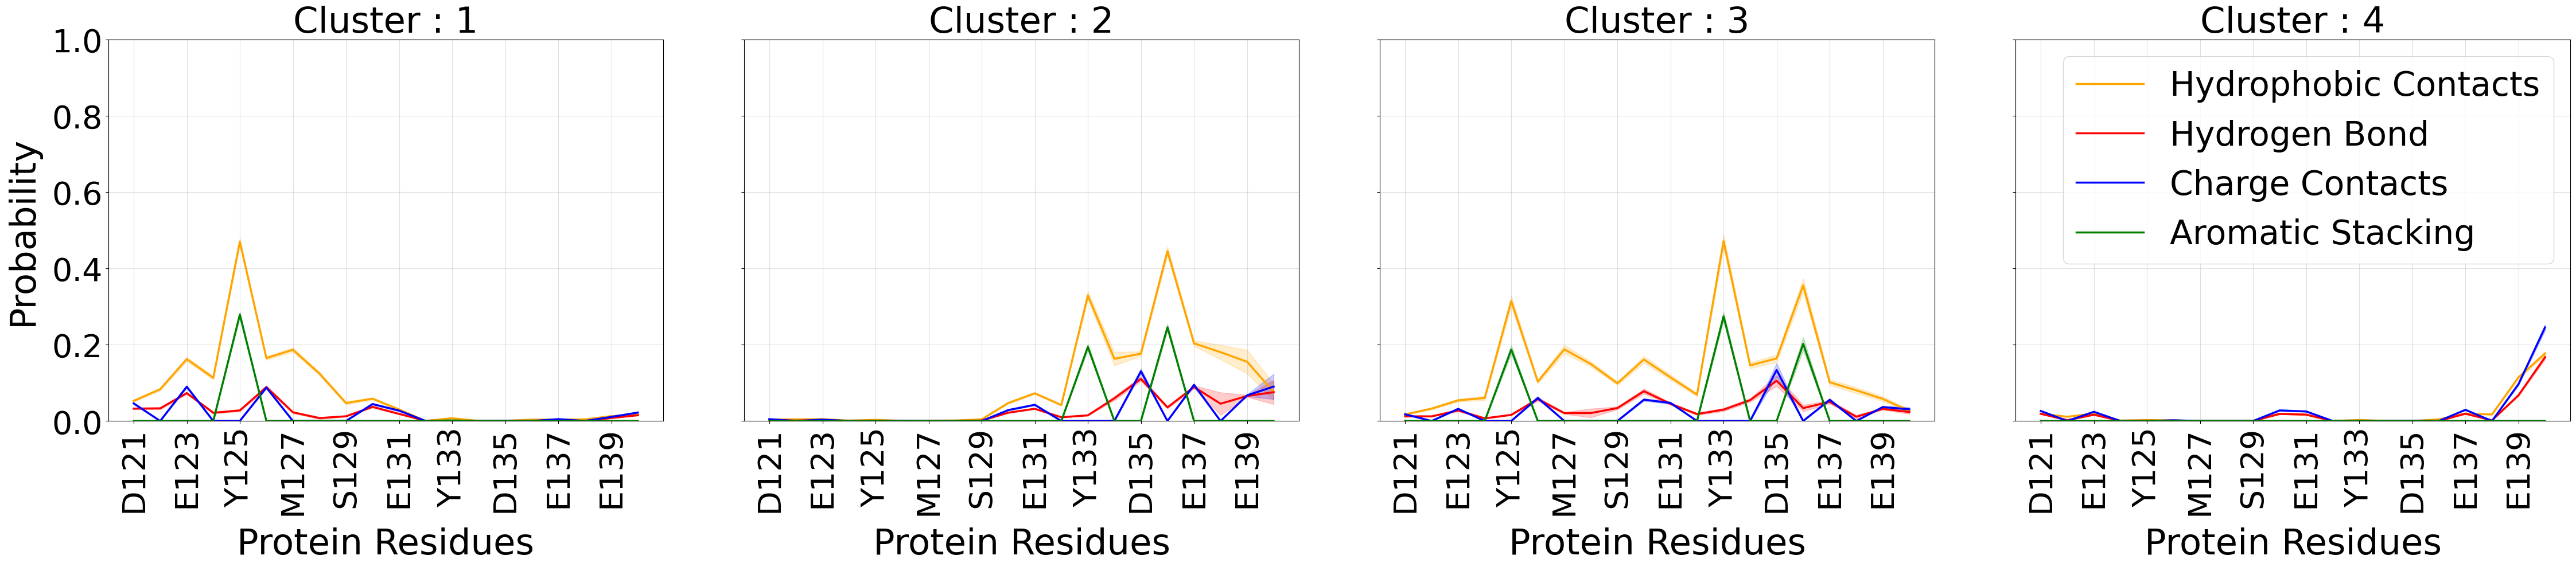

In [29]:
fig, ax = plt.subplots(1, 4, figsize=(45, 10), sharex=True, sharey=True)
#res = np.array([str(trj[0].topology.residue(i)) for i in range(20)])
res_ = ('D121','E123','Y125','M127','S129','E131','Y133','D135','E137','E139')

for i in range(4):
    p = np.unravel_index(i,(4))
    
    ax[p].plot(hydro[i].T[0], hydro[i].T[1], linewidth=2.5, label='Hydrophobic Contacts', color='orange')
    ax[p].fill_between(hydro[i].T[0], hydro[i].T[1]-hydro[i].T[2],
                          hydro[i].T[1]+hydro[i].T[2], alpha=0.2,color='orange')
    
    ax[p].plot(Hbond[i].T[0], Hbond[i].T[1], linewidth=2.5,label='Hydrogen Bond', color='red')
    ax[p].fill_between(Hbond[i].T[0], Hbond[i].T[1]-Hbond[i].T[2],
                          Hbond[i].T[1]+Hbond[i].T[2], alpha=0.2,color='r')
    
    ax[p].plot(charge_[i].T[0], charge_[i].T[1], linewidth=2.5,label='Charge Contacts',c='blue')
    ax[p].fill_between(charge_[i].T[0], charge_[i].T[1]-charge_[i].T[2],
                          charge_[i].T[1]+charge_[i].T[2], alpha=0.2,color='blue')
    
    ax[p].plot(aro_[i].T[0], aro_[i].T[1], linewidth=2.5, color='green', label='Aromatic Stacking')
    ax[p].fill_between(aro_[i].T[0], aro_[i].T[1]-aro_[i].T[2],
                         aro_[i].T[1]+aro_[i].T[2], alpha=0.2,color='green')
    
    ax[p].set_ylim(0,1.0)
    ax[p].set_xticks(range(int(min(Hbond[i][:,0])),int(max(Hbond[i][:,0])+1),2))
    ax[p].set_xticklabels(res_)
    ax[p].tick_params(labelsize=40)
    ax[p].grid(alpha=0.4)
    plt.setp(ax[p].get_xticklabels(), rotation=90)
    
    
    if i == 3:
        ax[p].legend(loc=1,prop={'size': 42})

    a='Cluster : '+str(i+1)
    ax[p].set_title(a,size=45)
    
    #text_=r'$K_{D}$'+' : '+str(round(K[2][i],2))+r'$\pm$'+str(round(K[3][i],2))
    #ax[p].text(120.3, 0.63, text_, fontsize = 26)
    
    ax[0].set_ylabel("Probability", size=45, labelpad=15)
    ax[p].set_xlabel('Protein Residues', size=45, labelpad=15)
        
plt.tight_layout()

## Save individual intermolecular feature arrays

This cell saves hydrogen-bond, charge, hydrophobic, and aromatic interaction features as `.npy` files so they can be reused without recalculating the full interaction analysis.

In [30]:
np.save("intermol_Hbond_pca_combined_lig.npy", Hbond)
np.save("intermol_charge_pca_combined_lig.npy", charge_)
np.save("intermol_aro_pca_combined_lig.npy", aro_)
np.save("intermol_hydro_pca_combined_lig.npy", hydro)

## Save combined intermolecular interaction matrix

This cell concatenates all major intermolecular interaction features into a single array and saves it for downstream analysis or visualization in the main PCA notebook.

In [1]:
interactions_all = np.hstack((hydro, Hbond, charge_, aro_))
np.save("intermol_interac_pca_combined_lig.npy", interactions_all)

## Summarize and sort cluster-angle statistics

This cell converts the cluster-angle measurements into a structured array, including average values and standard deviations for comparison across clusters.

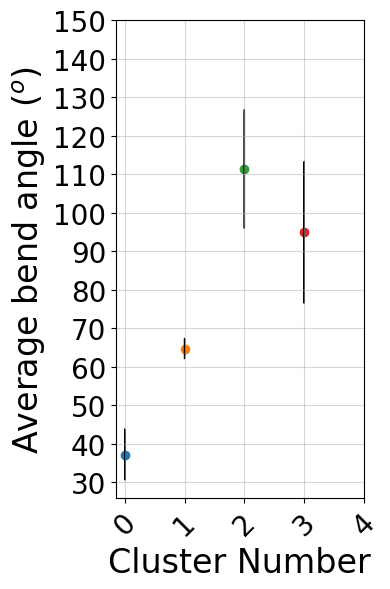

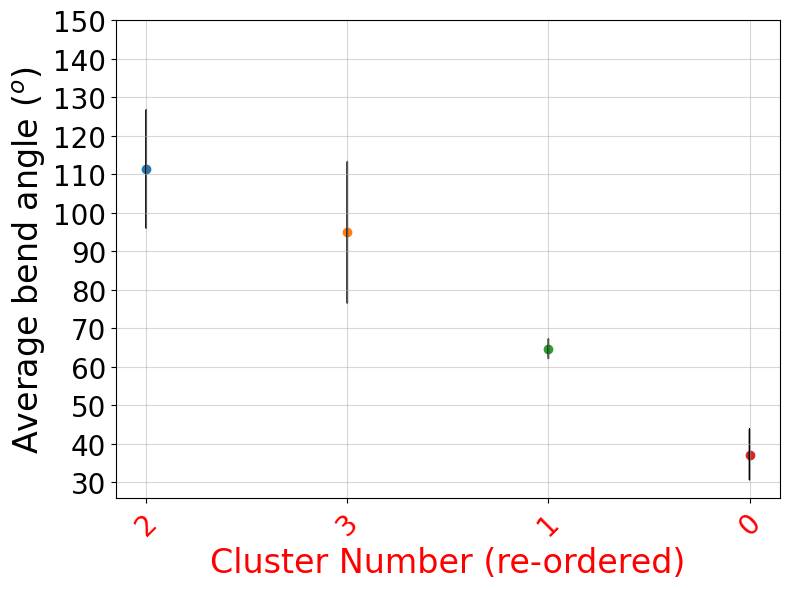

In [37]:
AA=[]
for i in range(len(A)): AA.append([i,np.average(A[i]),np.std(A[i])])
    
AA=np.asarray(AA)
AA_s=np.array(sorted(AA,key=lambda x: x[1], reverse=True))

plt.figure(figsize=(4,6))
for i in range(4):
    
    plt.scatter(AA.T[0][i],AA.T[1][i])
    plt.arrow(AA.T[0][i],(AA.T[1][i]-(AA.T[2][i]/2)),0,AA.T[2][i])
    
plt.xticks(range(0,5),size=20,rotation=45)
plt.yticks(range(30,160,10),size=20)
    
plt.xlabel("Cluster Number",size=24)
plt.ylabel("Average bend angle ($^{o}$)", size=24)
plt.grid(alpha=0.5)
plt.tight_layout()


plt.figure(figsize=(8,6))
for i in range(4):
    
    plt.scatter(i,AA_s.T[1][i])
    plt.arrow(i,(AA_s.T[1][i]-(AA_s.T[2][i]/2)),0,AA_s.T[2][i])

plt.xticks(range(0,4),AA_s.T[0].astype(int),size=20,rotation=45,color='r')
plt.yticks(range(30,160,10),size=20)
    
plt.xlabel("Cluster Number (re-ordered)",size=24, color='r')
plt.ylabel("Average bend angle ($^{o}$)", size=24)
plt.grid(alpha=0.5)
plt.tight_layout()

## Define peptide contact-map calculation

This cell defines a helper function for computing intramolecular peptide/protein contact maps within each PCA cluster.

In [31]:
# Computes protein/peptide intramolecular contact maps for a cluster.
def contact_map_protein_(trj,cutoff=1.2):
    
    contact_maps = []
    contact_distances = []
    for i in range(0, 20):
        contact_map = []
        contact_distance = []
        for j in range(0, 20):
            if i == j:
                contacts = 0
            else:
                dist = md.compute_contacts(trj, [[i, j]])
                array = np.asarray(dist[0]).astype(float)
                #distance = np.average(array)
                #contact_distance.append(np.average(array))
                #contact = np.where(array < cutoff, 1, 0)
                contacts = np.average(np.where(array < cutoff, 1, 0))
            contact_map.append(contacts)
        contact_maps.append(contact_map)
        #contact_distances.append(contact_distance)

    final_map = np.asarray(contact_maps).astype(float)
    #final_distance = np.asarray(contact_distances).astype(float)
    
    return final_map

## Calculate peptide contact maps by cluster

This cell applies the peptide contact-map function to each PCA cluster and stores the resulting contact matrices.

In [33]:
C=[]
for i in range(4):
    c=contact_map_protein_(trj[i])
    
    C.append(c)

## Save peptide contact maps

This cell saves the cluster-wise peptide contact maps as a `.npy` file for later reuse.

In [34]:
np.save("pep_contact_pca_combined_lig.npy", C)

## Define heatmap plotting helper

This cell defines a reusable seaborn heatmap function for visualizing contact maps with consistent formatting.

In [35]:
# Plots a formatted heatmap on a supplied matplotlib axis.
def subplot_snsheat(data, ax=None, cbar=False, cbar_ax=None):
    from numpy import ndarray
    import seaborn as sns
    if type(data) is ndarray:

        if ax is None:
            ax = plt.gca()

        plot = sns.heatmap(data, cmap='Blues', vmin=0,vmax=1.0,ax=ax, cbar=cbar, cbar_ax=None if not cbar else cbar_ax)
        return plot

    else: pass
    
# Defines the `subplot_imshow` helper used in the cluster interaction workflow.
def subplot_imshow(data, xedges, yedges, ax=None):
    
    from numpy import ndarray
    
    if type(data) is ndarray:

        if ax is None:
            ax = plt.gca()
            
        im = ax.imshow(data, interpolation='gaussian', extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                        cmap='jet', aspect='auto')
        #cb = plt.colorbar(ticks=cbar_ticks, format=('% .1f'),aspect=10)
        
        return im
    
    else : pass

## Define residue labels for contact-map plots

This cell defines sequence labels used to annotate contact-map heatmaps with residue identities.

In [36]:
sequence=  ['ASP121', '', 'GLU123', '', 'TYR125', '', 'MET127', '', 'SER129', '', 'GLU131', '',\
            'TYR133', '', 'ASP135', '', 'GLU137', '', 'GLU139', 'ALA140']

## Plot peptide contact maps across clusters

This cell visualizes the cluster-wise peptide contact maps, allowing protein conformational differences across PCA states to be compared.

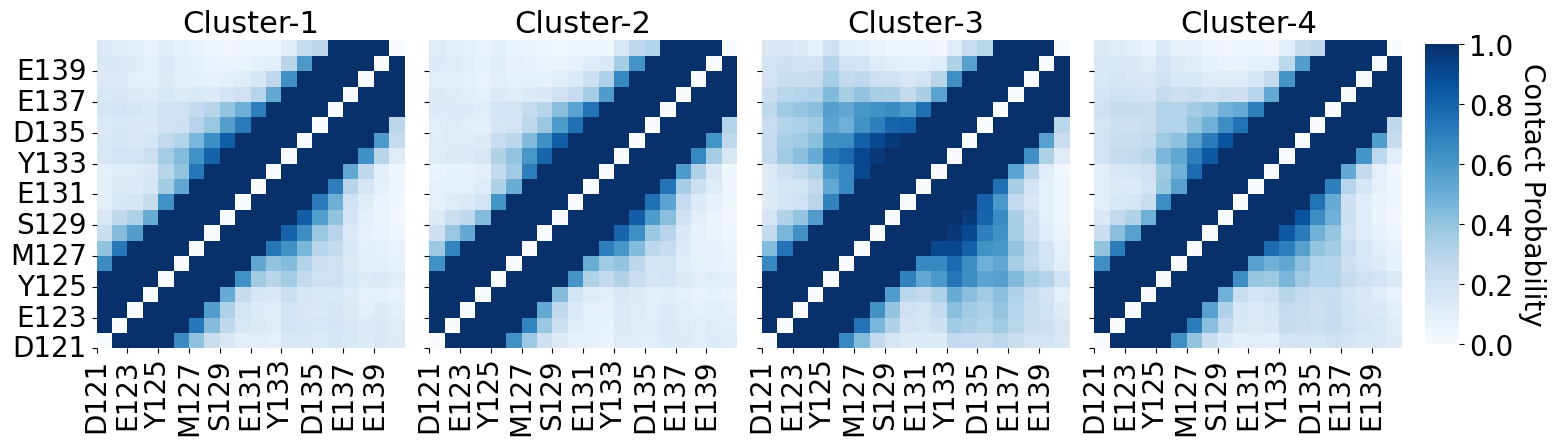

In [37]:
ncol = 4
nrow = 1
fig, ax = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(17, 4))
cbar_ax = fig.add_axes([.91, .12, .02, .75])

for i in range(4):
    #contact_map = np.loadtxt(f"./Analysis/contact_map.{i}.dat")
    contact_map = C[i]
    p = np.unravel_index(i,(5))
    cb = i==1
    subplot_snsheat(contact_map, ax=ax[p], cbar=cb, cbar_ax=cbar_ax)
    ax[p].set_xticks(range(0, 20,2), res_, rotation=90, size=20)
    ax[p].set_yticks(range(0, 20,2), res_, rotation=0, size=20)
    ax[p].invert_yaxis()
    ax[p].set_aspect('equal', 'box')
    ax[p].set_title('Cluster-'+str(i+1),size=22)
cbar_ax.tick_params(labelsize=20)
cbar_ax.set_ylabel('Contact Probability', rotation=270, fontsize = 20, labelpad=24)
    
plt.subplots_adjust(wspace=0.04, hspace=0)

## Define ligand-protein dual contact-map calculation

This cell defines a helper function for computing ligand-residue contact maps for each PCA cluster.

In [38]:
# Computes ligand-protein contact maps for a cluster.
def contact_map_ligand_(trj,ligand_res_index,cutoff=0.6):

    contact_maps = []
    for i in range(0, 20):
        # print(i)
        contact_map = []
        for j in range(0, 20):
            dist1 = md.compute_contacts(trj, [[i, ligand_res_index]], scheme='closest-heavy')
            dist2 = md.compute_contacts(trj, [[j, ligand_res_index]], scheme='closest-heavy')
            array1 = np.asarray(dist1[0]).astype(float)
            array2 = np.asarray(dist2[0]).astype(float)
            contact1 = np.where(array1 < cutoff, 1, 0)
            contact2 = np.where(array2 < cutoff, 1, 0)
            sum = contact1 + contact2
            #contact = np.where(sum == 2, 1, 0)
            contacts = np.average(np.where(sum == 2, 1, 0))
            contact_map.append(contacts)
        contact_maps.append(contact_map)
        
    return np.asarray(contact_maps).astype(float)

## Calculate ligand-protein dual contact maps by cluster

This cell applies the ligand contact-map function across PCA clusters and stores the resulting cluster-specific maps.

In [39]:
C_=[]
for i in range(4):
    c_=contact_map_ligand_(trj[i],21)
    
    C_.append(c_)

## Save dual contact maps

This cell saves the cluster-wise ligand-protein contact maps as a `.npy` file for downstream comparison and figure generation.

In [40]:
np.save("dual_contact_pca_combined_lig.npy", C_)

## Plot ligand-protein dual contact maps

This cell visualizes Ligand-47 contact patterns across PCA clusters, highlighting how the ligand interacts with different protein regions in each binding mode.

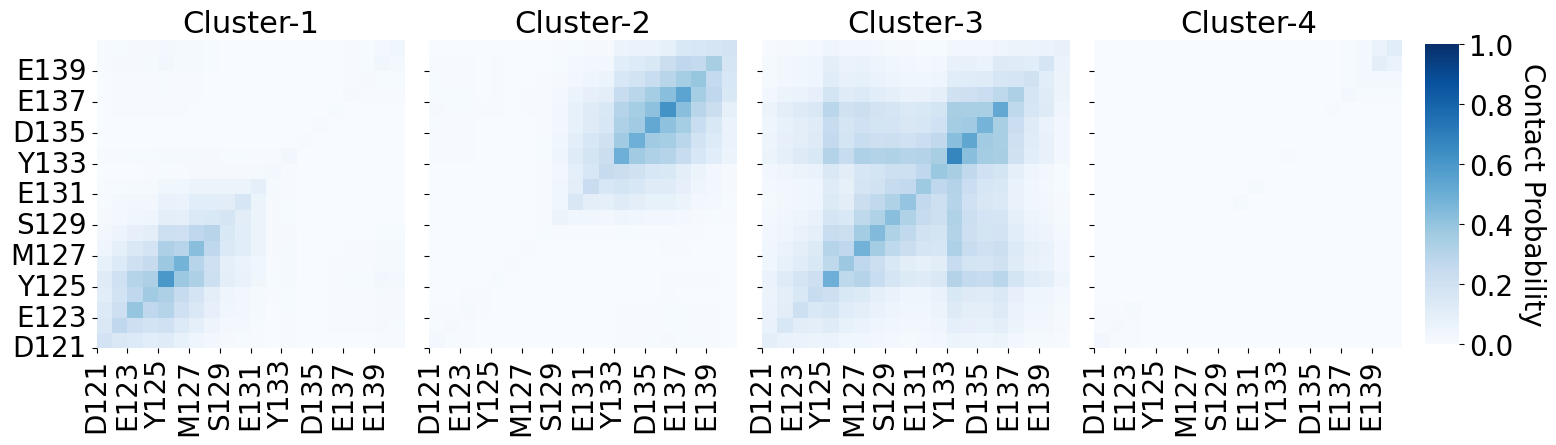

In [41]:
ncol = 4
nrow = 1
fig, ax = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(17, 4))
cbar_ax = fig.add_axes([.91, .12, .02, .75])

for i in range(4):
    #contact_map = np.loadtxt(f"./Analysis/contact_map.{i}.dat")
    contact_map = C_[i]
    p = np.unravel_index(i,(5))
    cb = i==1
    subplot_snsheat(contact_map, ax=ax[p], cbar=cb, cbar_ax=cbar_ax)
    ax[p].set_xticks(range(0, 20,2), res_, rotation=90, size=20)
    ax[p].set_yticks(range(0, 20,2), res_, rotation=0, size=20)
    ax[p].invert_yaxis()
    ax[p].set_aspect('equal', 'box')
    ax[p].set_title('Cluster-'+str(i+1),size=22)
cbar_ax.tick_params(labelsize=20)
cbar_ax.set_ylabel('Contact Probability', rotation=270, fontsize = 20, labelpad=24)
    
plt.subplots_adjust(wspace=0.04, hspace=0)